In [2]:
import pandas as pd
df=pd.read_csv('iris.csv')
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Features and target
X = df[['sepal.length', 'sepal.width',
        'petal.length', 'petal.width']]

y = df['variety']


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Vanilla Logistic Regression
model = LogisticRegression(penalty=None)

model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Accuracy
accuracy = accuracy_score(y_test, y_pred)
acc_train=accuracy_score(y_train, model.predict(X_train))
print("Vanilla Logistic Regression")
print("Accuracy(train):", acc_train)
print("Accuracy(test):", accuracy)


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Vanilla Logistic Regression
Accuracy(train): 0.9833333333333333
Accuracy(test): 1.0

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



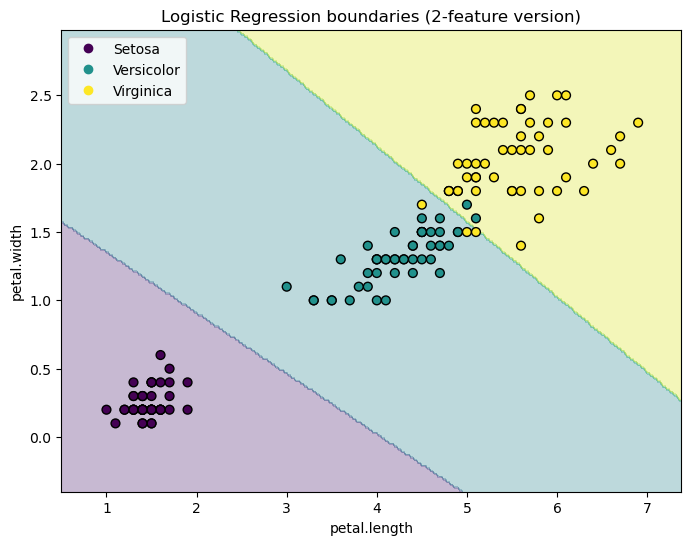

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import pandas as pd
# Import drive

# Mount Google Drive to ensure file access


# Re-define df to ensure it's available in this cell, using the path from M7X4XPYMWRIy
df = pd.read_csv('iris.csv')

# 1. Two features only, so the boundary is drawable.
# Correct column names to match the loaded DataFrame
fx, fy = 'petal.length', 'petal.width'
X2 = df[[fx, fy]].values
# Correct target column name to 'variety'
y_codes, classes = pd.factorize(df['variety'])     # 'Setosa'.. -> 0/1/2

# 2. A SEPARATE 2-feature model. NOT your 4-feature model.
viz = LogisticRegression(penalty=None, max_iter=1000)
viz.fit(X2, y_codes)          # unscaled on purpose — see note below

# 3. Grid over the feature space, predict class at every point.
x_min, x_max = X2[:,0].min()-0.5, X2[:,0].max()+0.5
y_min, y_max = X2[:,1].min()-0.5, X2[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 4. Colored regions = model's decision; dots = real flowers.
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
sc = plt.scatter(X2[:,0], X2[:,1], c=y_codes, cmap='viridis',
                 edgecolor='k', s=40)
plt.xlabel(fx); plt.ylabel(fy)
plt.title('Logistic Regression boundaries (2-feature version)')
plt.legend(handles=sc.legend_elements()[0], labels=list(classes))
plt.show()